## Intro 

In [2]:
import wget
import os
import healpy as hp
import numpy as np
import pylab as pl 
from pathlib import Path
import scipy
from scipy.odr import Model, Data, ODR
from scipy.optimize import curve_fit

from astropy import units as u, constants as const

from astropy.io import fits

def b(nu):
    """
    estimate dI/dT_CMB as defined in eq. 8 of Planck 2013 IX
    """
    nu0 = 56.8 * u.GHz
    x = nu / nu0
    Tcmb = 2.7255 * u.K
    bb = (
        2
        * const.h
        * nu ** 3
        / const.c ** 2
        / Tcmb
        * (x * np.exp(x) / (np.exp(x) - 1) ** 2)
    )
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)


def b_rj(nu):
    """
    estimate dI/dT_RJ as defined in eq. 30 of Planck 2013 IX
    """
    bb = 2 * const.k_B * nu ** 2 / const.c ** 2
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)

def brightness2Tcmb(nu, bandpass=None):
    """
    Convert from Jy/srad  to K_CMB
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def brightness2Trj(nu, bandpass=None):
    """
    Convert from Jy/srad to K_RJ
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b_rj(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b_rj(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def Krj2Kcmb(nu, Trj=1.0, bandpass=None):
    """
    Convert antenna temperature ( Rayleigh-Jeans) into the physical one
    """
    return Trj / Kcmb2Krj(
        nu=nu, Tcmb=1, bandpass=bandpass
    )  # (x ** 2 * np.exp(x) / (np.exp(x) - 1) ** 2)


def Kcmb2Krj(nu, Tcmb=1.0, bandpass=None):
    return (
        brightness2Trj(nu=nu, bandpass=bandpass)
        / brightness2Tcmb(nu=nu, bandpass=bandpass)
        * Tcmb
    )

def planckcorr(freq_ghz):
    """ Takes in frequency in GHZ and produces factor to be applied to temp """

    freq = freq_ghz * 10.**9.
    CST = {"kbolt": 1.3806488e-23, "light": 2.99792458e8, "plancks": 6.626e-34, "cmb_temp": 2.725}
    factor = CST["plancks"] * freq / (CST["kbolt"] * CST["cmb_temp"])
    correction = (np.exp(factor)-1.)**2. / (factor**2. * np.exp(factor))

    return correction



## Disclaimer 

applying few changes on Mel code for fine reso maps. 
- downgrading maps at `nside=256`
- smoothing maps at `fwhm=1.2 deg`
this is mainly because , there ain't no need to run with `nside=512` (6.9 arcmin), the pixel reso at 256   (13.7 arcmin ) is enough for degree reso . also want to push as much as i could the resolution of maps towards the degree scale. 

Offsets estimated for Q11 in any case are in any case bad. see plot below. 


In [3]:
folder_path = "../ovro_lwa_data"
Path(folder_path).mkdir(parents=True, exist_ok=True)

In [4]:
from scipy.odr import Model, Data, ODR
from scipy.stats import linregress

def rotate_map(mapin, coord_in , coord_out ) : 
    alm = hp.map2alm (mapin )
    R=  hp.Rotator(coord=[coord_in, coord_out ])
    alm =  R.rotate_alm (alm )
    map_out = hp.alm2map (alm , nside= hp.get_nside(mapin ))
    return map_out


def get_betas(xdat, xnoise, ydat, ynoise, v1, v2):
    """perform linear regression between two data set and get spectral index """

    mydata = Data(xdat, ydat, wd=xnoise**-2, we=ynoise**-2)
    myodr = ODR(mydata, Model(sform), beta0=[0.05, 0.5])
    myoutput = myodr.run()
    fitted_gradient = myoutput.beta[0]
    error_gradient = myoutput.sd_beta[0]

    ef = np.log(v2/v1)
    beta = np.log(fitted_gradient) / ef
    beta_error = error_gradient / (fitted_gradient * ef)

    #if beta > -2.1 or beta < -3.5:
    #    plt.plot(xdat, ydat, '.')
    #    plt.plot(xdat, fitted_gradient*xdat +  myoutput.beta[1], 'r-')
    #    plt.show()

    #    print("breaking here")
    
    return beta, beta_error, myoutput 
    
def sform(param, xxx):
    '''linear reggression'''
    return xxx * param[0] + param[1]
def fitting_beta_curvature(X, beta, cs):
   return beta*X +cs*X*X 

def sfunc(xxx, bval, cval):
    '''linear reggression'''
    return xxx * bval + cval


def remove_off(map, hasmap, maperr, haserr  ):
    nside_superpix=8
    nan1 =np.ma.masked_invalid (map).mask 
    npix = map.size 
    pixs = np.arange(npix)
    try : 
        ang = hp.pix2ang(ipix= pixs[nan1][0] , nside= hp.get_nside(map)) 
        pix1 = hp.ang2pix(theta=ang[0] , phi = ang[1] , nside= nside_superpix)
    

        if pixs[nan1] [0]==0 :
            print("Southern Survey ") 
            super_pixs=  np.arange(pix1, hp.nside2npix(nside_superpix)) 
        else: 
            print("Northern survey ")
            super_pixs=  np.arange(pix1) 
    except IndexError: 
        print('Fullsky survey')
        super_pixs=  np.arange(hp.nside2npix(nside_superpix )) 
    offsets = np.zeros_like(super_pixs)*1. 
    offmap = np.full(hp.nside2npix(nside_superpix), np.nan)  
   

    nansize =0 
    for jj, ipix in enumerate(super_pixs) : 

        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map [ipix] =1
        patch =  (hp.ud_grade(super_map, nside_out=hp.get_nside(map))) .astype('bool')
     
        try:
            
            errx = haserr[patch] * hasmap[patch]
            erry =  maperr * map[patch]
            mydata = Data(hasmap[patch], map[patch], wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]
            if np.corrcoef(hasmap[patch].value, map[patch].value)[0,1] > 0.85:
                offsets[jj] = cfit
            else:
                offsets[jj] = np.nan
        except  ValueError: 
            nansize+=1 
            offsets[jj]= np.nan 
            
    offmap[super_pixs] = offsets 

    #avec = np.nanmean( offsets ) *map.unit 
    avec = np.nanmedian( offsets ) *map.unit 
    map = map - avec
    
    return map, avec  , np.nanstd(offsets) /np.sqrt(offsets.size - nansize), offmap 
 


https://lambda.gsfc.nasa.gov/product/wmap/dr5/ 

https://lambda.gsfc.nasa.gov/product/foreground/fg_all_sky150_mhzmap_get.html



https://lambda.gsfc.nasa.gov/data/map/dr5/skymaps/9yr/deconv/images/wmap_band_deconv_imap_r9_9yr_K_v5.fits

https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/haslam408_ds_Remazeilles2014.fits

https://lda10g.alliance.unm.edu/LWA1LowFrequencySkySurvey/
https://lambda.gsfc.nasa.gov/data/foregrounds/lwa1/healpix-all-sky-rav-wsclean-map-50.fits

https://lambda.gsfc.nasa.gov/product/foreground/fg_rhodes_hart_info.html


## REad maps 

In [5]:
#freqs=np.array([
#    36.528, 41.760, 46.992, 52.224, 57.456, 62.688, 67.920, 73.152
#    ]) 
freqs=np.array([
    41.760, 46.992, 52.224, 57.456, 62.688, 67.920, 73.152
    ]) 
maps={}
mapserr={}
offerr={}

cwd = Path.cwd() 
for j,fr in enumerate(freqs) :
    if fr == 41.76:
        fstring=(f"ovro_lwa_sky_map_41.760MHz.fits")
    elif fr == 67.92:
        fstring=(f"ovro_lwa_sky_map_67.920MHz.fits")
    else:
        fstring=(f"ovro_lwa_sky_map_{fr}MHz.fits")
    
    try : 
        print(f"reading {fstring} ")
        maps[fr],_=  hp.read_map(f"../ovro_lwa_data/{fstring}" ,h=True  )
    except FileNotFoundError: 
        filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/ovro/{fstring}", out ="../ovro_lwa_data")
        maps[fr]=  hp.read_map(f"../ovro_lwa_data/{fstring}"  )
    
    zeros = np.where(maps[fr] == 0.0)
    maps[fr][zeros] = np.nan 

    maps[fr]*=u.K
    mapserr[fr] = 0.05 # 5 per cent for LWA calibration 
    offerr[fr] = 0.0

fstring="haslam408_ds_Remazeilles2014.fits"

try :
    print(f"reading {fstring} ")

    maps[408],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/{fstring}", out ="../ovro_lwa_data")
    maps[408]=  hp.read_map(f"../lwa_data/{fstring}"  )


maps[408]= (maps[408]*u.K -8.9*u.K ).to(maps[41.760].unit)
mapserr[408] = np.sqrt((0.1 * maps[408].value)**2 + 1.3**2) /  maps[408].value # 10 per cent for 408 calibration plus the 1.3K offset error
offerr[408] = 0.0 # it has already been added to maperr


fstring="GMIMS-HBN_v1_gal_hpx_freq_I.fits"
try :
        
    print(f"reading {fstring} ")

    hdul = fits.open(f"../lwa_data/GMIMS-HBN_v1_gal_hpx_freq_I.fits" ) 
except FileNotFoundError: 
    filename = wget.download( f"https://www.canfar.net/storage/vault/file/AstroDataCitationDOI/CISTI.CANFAR/21.0003/data/release/{fstring}", out ="../lwa_data")
    hdul = fits.open(f"../lwa_data/GMIMS-HBN_v1_gal_hpx_freq_I.fitss" )

header = hdul[0].header
data = hdul[0].data

#horrible RFI - missing data patches before map = 90
maps[1383] = data[90, :]
maps[1383]= (maps[1383]*u.K   ).to(maps[41.760].unit) 
offerr[1383] = 0.0
mapserr[1383] = 0.08 

maps[1418] = data[120, :]
maps[1418]= (maps[1418]*u.K   ).to(maps[41.760].unit) 
offerr[1418] = 0.0
mapserr[1418] = 0.08 

maps[1456] = data[152, :]
maps[1456]= (maps[1456]*u.K   ).to(maps[41.760].unit) 
offerr[1456] = 0.0
mapserr[1456] = 0.08 

maps[1487] = data[180, :]
maps[1487]= (maps[1487]*u.K   ).to(maps[41.760].unit) 
offerr[1487] = 0.0
mapserr[1487] = 0.08 

maps[1499] = data[190, :]
maps[1499]= (maps[1499]*u.K   ).to(maps[41.760].unit) 
offerr[1499] = 0.0
mapserr[1499] = 0.08 

maps[1521] = data[209, :]
maps[1521]= (maps[1521]*u.K   ).to(maps[41.760].unit) 
offerr[1521] = 0.0
mapserr[1521] = 0.08

maps[1614] = data[285, :]
maps[1614]= (maps[1614]*u.K   ).to(maps[41.760].unit) 
offerr[1614] = 0.0
mapserr[1614] = 0.08 

maps[1625] = data[300, :]
maps[1625]= (maps[1625]*u.K   ).to(maps[41.760].unit) 
offerr[1625] = 0.0
mapserr[1625] = 0.08 

maps[1660] = data[330, :]
maps[1660]= (maps[1660]*u.K   ).to(maps[41.760].unit) 
offerr[1660] = 0.0
mapserr[1660] = 0.08 

maps[1700] = data[358, :]
maps[1700]= (maps[1700]*u.K   ).to(maps[41.760].unit) 
offerr[1700] = 0.0
mapserr[1700] = 0.08 

maps[1712] = data[368, :]
maps[1712]= (maps[1712]*u.K   ).to(maps[41.760].unit) 
offerr[1712] = 0.0
mapserr[1712] = 0.08 

nside=256 # hp.get_nside(maps[408] )
npix= hp.nside2npix(nside)

reading ovro_lwa_sky_map_41.760MHz.fits 
reading ovro_lwa_sky_map_46.992MHz.fits 
reading ovro_lwa_sky_map_52.224MHz.fits 
reading ovro_lwa_sky_map_57.456MHz.fits 
reading ovro_lwa_sky_map_62.688MHz.fits 
reading ovro_lwa_sky_map_67.920MHz.fits 
reading ovro_lwa_sky_map_73.152MHz.fits 
reading haslam408_ds_Remazeilles2014.fits 
reading GMIMS-HBN_v1_gal_hpx_freq_I.fits 


## smoothing to common reso 

In [6]:
freqs  =  np.array([  k for k in maps.keys()  ])  
nside=256 
fwhms = {#36.528: 19.1*u.arcmin, 
         41.760: 17.5 *u.arcmin , 
         46.992: 16.3*u.arcmin,
         52.224: 15.2*u.arcmin,
         57.456: 14.9*u.arcmin,
         62.688: 15.0*u.arcmin,
         67.920: 15.0*u.arcmin,
         73.152: 15.1*u.arcmin,
         408.: 56.*u.arcmin,
         1280: 40.*u.arcmin,
         1315: 40.*u.arcmin,
         1349: 40.*u.arcmin,
         1383: 40.*u.arcmin,
         1418: 40.*u.arcmin,
         1456: 40.*u.arcmin,
         1487: 40.*u.arcmin,
         1499: 40.*u.arcmin,
         1521: 40.*u.arcmin,
         1614: 40.*u.arcmin,
         1625: 40.*u.arcmin,
         1660: 40.*u.arcmin,
         1700: 40.*u.arcmin,
         1712: 40.*u.arcmin,
         } 

## smooth maps to 1.0 degrees
fwhmax = (1.2 *u.deg ).to(fwhms[41.760].unit) 
# downgrade them to nside=512
print("smoothing and downgrading maps ")
noise_factor={} 
for k  in freqs:
    nans= np.ma.masked_invalid(maps[k] ).mask
    maps[k] [nans] =hp.UNSEEN *maps[k].unit
    maps[k] = hp.smoothing(maps[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit
    noise_factor[k] = np.sqrt(hp.nside2npix(hp.get_nside (maps[k ])) /hp.nside2npix( nside )  )

    if hp.get_nside(maps[k]) != nside  : 
        maps[k] = hp.ud_grade(maps[k].value , nside_out=nside)*maps[k].unit
    if k == 408:
      mapserr[k] = hp.smoothing(mapserr[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit
      mapserr[k] = hp.ud_grade(mapserr[k].value , nside_out=nside )*maps[k].unit
    nans= np.ma.masked_equal(maps[k].value, hp.UNSEEN  ).mask
    maps[k][nans] = np.nan 

smoothing and downgrading maps 


## error bars 


In [13]:

from scipy import integrate

def beamsolidangle(fwhm):
    """
    Given a FWHM resolution `fwhm`,
    it computes the solid angle subtended by a Gaussian-axisymmetric beam
     in steradians by performing :

    .. math::
        \Delta \Omega = \int d \phi  d\theta  \sin(theta) \e^{-\theta^2/(2\sigma_b^2)}
    """

    sigma = (fwhm / 2 / np.sqrt(2 * np.log(2))).to(u.rad).value
    
    x = np.linspace(0, 4 * sigma, 2048)
    Gaussian = lambda theta: np.exp(-((theta / (np.sqrt(2) * sigma)) ** 2))
    integrand = lambda theta: 2 * np.pi * np.sin(theta) * Gaussian(theta)
    Solid_angle = (
        integrate.quad(integrand, 0, x.max(), limit=1000, epsrel=1.0e-5)[0] * u.sr
    )
    return Solid_angle
freqs=np.array([
    41.760, 46.992, 52.224, 57.456, 62.688, 67.920, 73.152
    ]) 
errors ={} 

errors_ovro =0.8 ### Jy/beam
 

for f in freqs  : 

    errors [f] = (errors_ovro *u.Jy/beamsolidangle(fwhms[f])).to(u.K,equivalencies=u.brightness_temperature(f*u.MHz))

for f in fwhms.keys() : 
    if f >1000 : 
        errors [f] = (20  *u.mK).to(u.K ) # sect. 4 in https://iopscience.iop.org/article/10.3847/1538-3881/abf7c1/pdf  but table 5 states 20 mK  


errors[408]= 0.1 *u.K # searching r.m.s. in https://arxiv.org/pdf/1411.3628 sigma_destr = 0.1 K 

storerrors ={} 
for f in maps.keys() : 
    storerrors[str(f)] = errors[f].value #/noise_factor[f] 

np.savez(f"../inputmaps/fine_north_errors_dict.npz", **storerrors)



for k  in sorted(maps.keys())  : 
    print(f"At {k} MHz , map error is {storerrors[str(k)]} ") 

At 41.76 MHz , map error is 508.6871548081155 
At 46.992 MHz , map error is 463.04659177673943 
At 52.224 MHz , map error is 431.1419100592076 
At 57.456 MHz , map error is 370.68443505700003 
At 62.688 MHz , map error is 307.2531349373647 
At 67.92 MHz , map error is 261.73981848295114 
At 73.152 MHz , map error is 222.6595734547553 
At 408 MHz , map error is 0.1 
At 1383 MHz , map error is 0.02 
At 1418 MHz , map error is 0.02 
At 1456 MHz , map error is 0.02 
At 1487 MHz , map error is 0.02 
At 1499 MHz , map error is 0.02 
At 1521 MHz , map error is 0.02 
At 1614 MHz , map error is 0.02 
At 1625 MHz , map error is 0.02 
At 1660 MHz , map error is 0.02 
At 1700 MHz , map error is 0.02 
At 1712 MHz , map error is 0.02 


<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_26291/133346180.py:4: SyntaxWarning: invalid escape sequence '\D'
  """


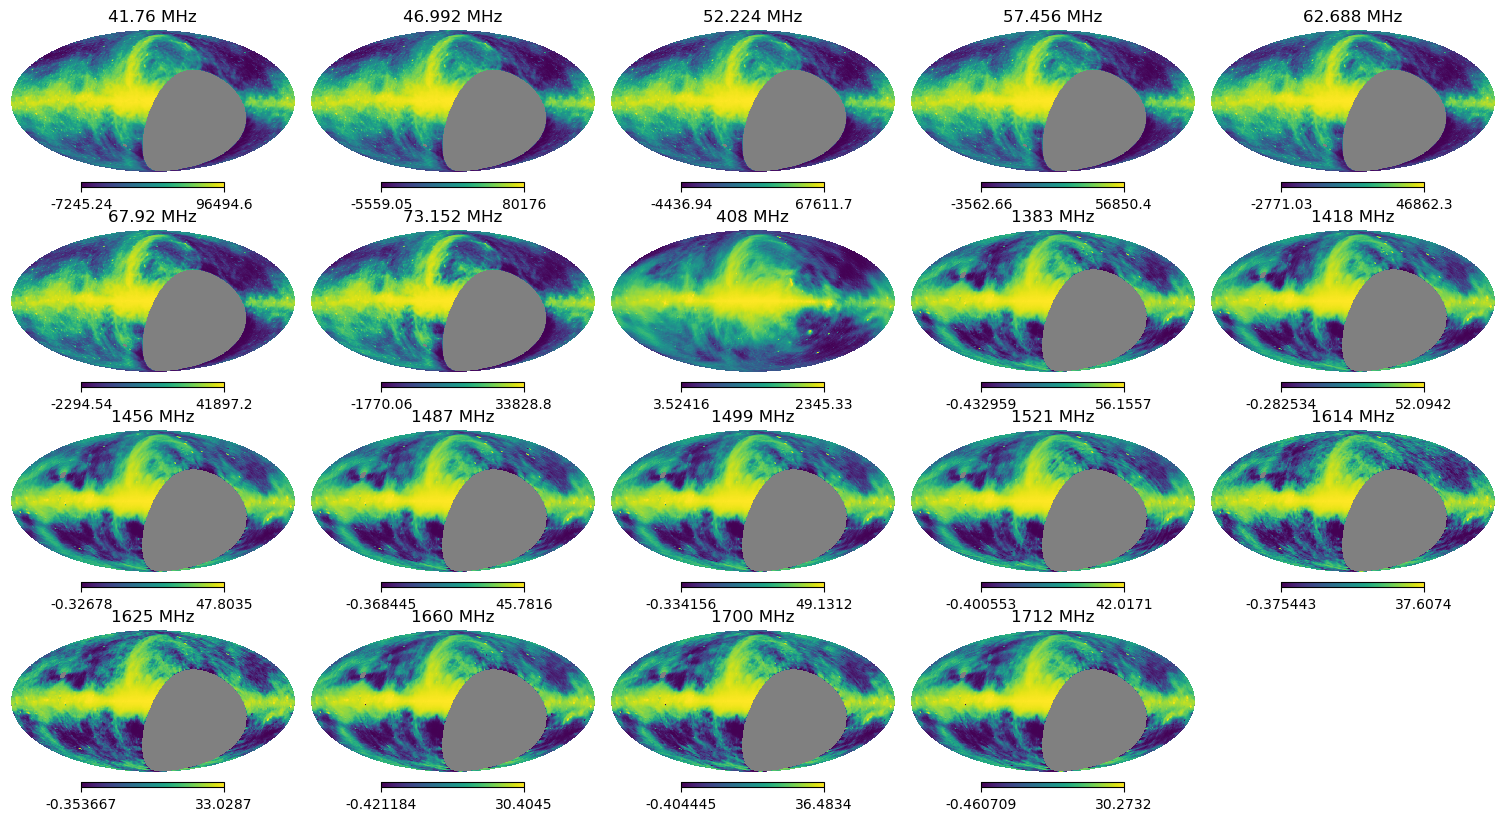

In [8]:
pl.figure(figsize=(15,10)) 

j=0
for fr,m in maps.items():
     
    hp.mollview( (m.value),  title=f'{fr} MHz'  , sub=(5,5,1+j) , notext=True ,norm='hist'   )
    
    j+=1

## Offset removal 

In [9]:


offerr={}
off_map = {} 
offsetvals = {} 


offsetvals = {}
def remove_off(map, hasmap, maperr, haserr  ):
    nside_superpix=8
    nan1 =~np.ma.masked_invalid (map).mask 
    npix = map.size 
    pixs = np.arange(npix)
    super_nans = hp.ud_grade(nan1.astype('int'), nside_out=nside_superpix).astype('bool') 
    super_pixs = np.arange(super_nans.size ) [super_nans] 
     
    offsets = np.zeros_like(super_pixs  )*1. 
    offmap = np.full(hp.nside2npix(nside_superpix), np.nan)     
    nansize =0 

    for jj, ipix in enumerate(super_pixs ) : 

        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map [ipix] =1
        

        patch =  (hp.ud_grade(super_map, nside_out=hp.get_nside(map))) .astype('bool')
     
        try:
            
            errx = haserr[patch] * hasmap[patch]
            erry =  maperr * map[patch]
            mydata = Data(hasmap[patch], map[patch], wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]
            if np.corrcoef(hasmap[patch].value, map[patch].value)[0,1] > 0.75:
                offsets[jj] = cfit
            else:
                offsets[jj] = np.nan
        except  ValueError: 
            nansize+=1 
            offsets[jj]= np.nan 

    offmap[super_pixs] = offsets

    #avec = np.nanmean( offsets ) *map.unit
    avec = np.nanmedian( offsets ) *map.unit
    map = map - avec
    
    return map, avec  , np.nanstd(offsets) /np.sqrt(offsets.size - nansize), offmap 

for k in maps.keys():
    if k ==408 : continue
    maps[k], offsetvals[k], offerr[k], off_map[k] = remove_off(maps[k], maps[408], mapserr[k], mapserr[408])
    print(f" {k} MHz data estimated offset: {offsetvals[k]:.4f} ± {offerr[k]:.4f}")


 

 41.76 MHz data estimated offset: -7628.2188 K ± 186.6108
 46.992 MHz data estimated offset: -5479.4011 K ± 149.7471
 52.224 MHz data estimated offset: -4170.9493 K ± 113.6781
 57.456 MHz data estimated offset: -3309.0005 K ± 83.5497
 62.688 MHz data estimated offset: -2537.9804 K ± 66.4301
 67.92 MHz data estimated offset: -2059.5254 K ± 52.3192
 73.152 MHz data estimated offset: -1588.5759 K ± 40.4868
 1383 MHz data estimated offset: -0.4687 K ± 0.0191
 1418 MHz data estimated offset: -0.3950 K ± 0.0177
 1456 MHz data estimated offset: -0.3761 K ± 0.0164
 1487 MHz data estimated offset: -0.3892 K ± 0.0156
 1499 MHz data estimated offset: -0.3646 K ± 0.0157
 1521 MHz data estimated offset: -0.3996 K ± 0.0161
 1614 MHz data estimated offset: -0.4240 K ± 0.0143
 1625 MHz data estimated offset: -0.3480 K ± 0.0142
 1660 MHz data estimated offset: -0.3186 K ± 0.0310
 1700 MHz data estimated offset: -0.3114 K ± 0.0121
 1712 MHz data estimated offset: -0.3047 K ± 0.0221


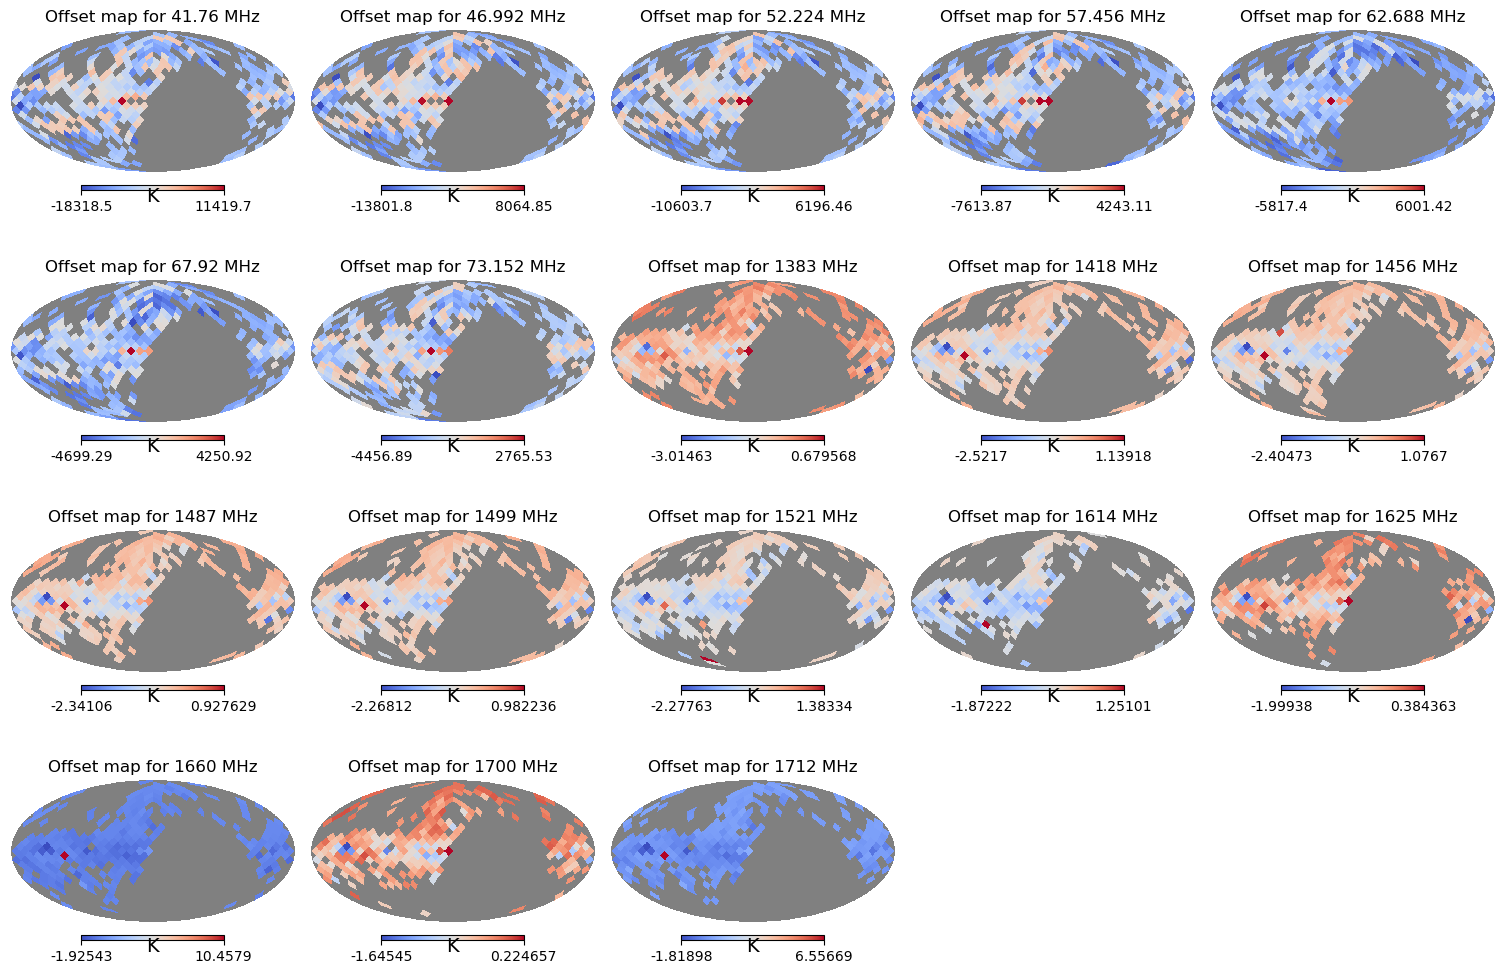

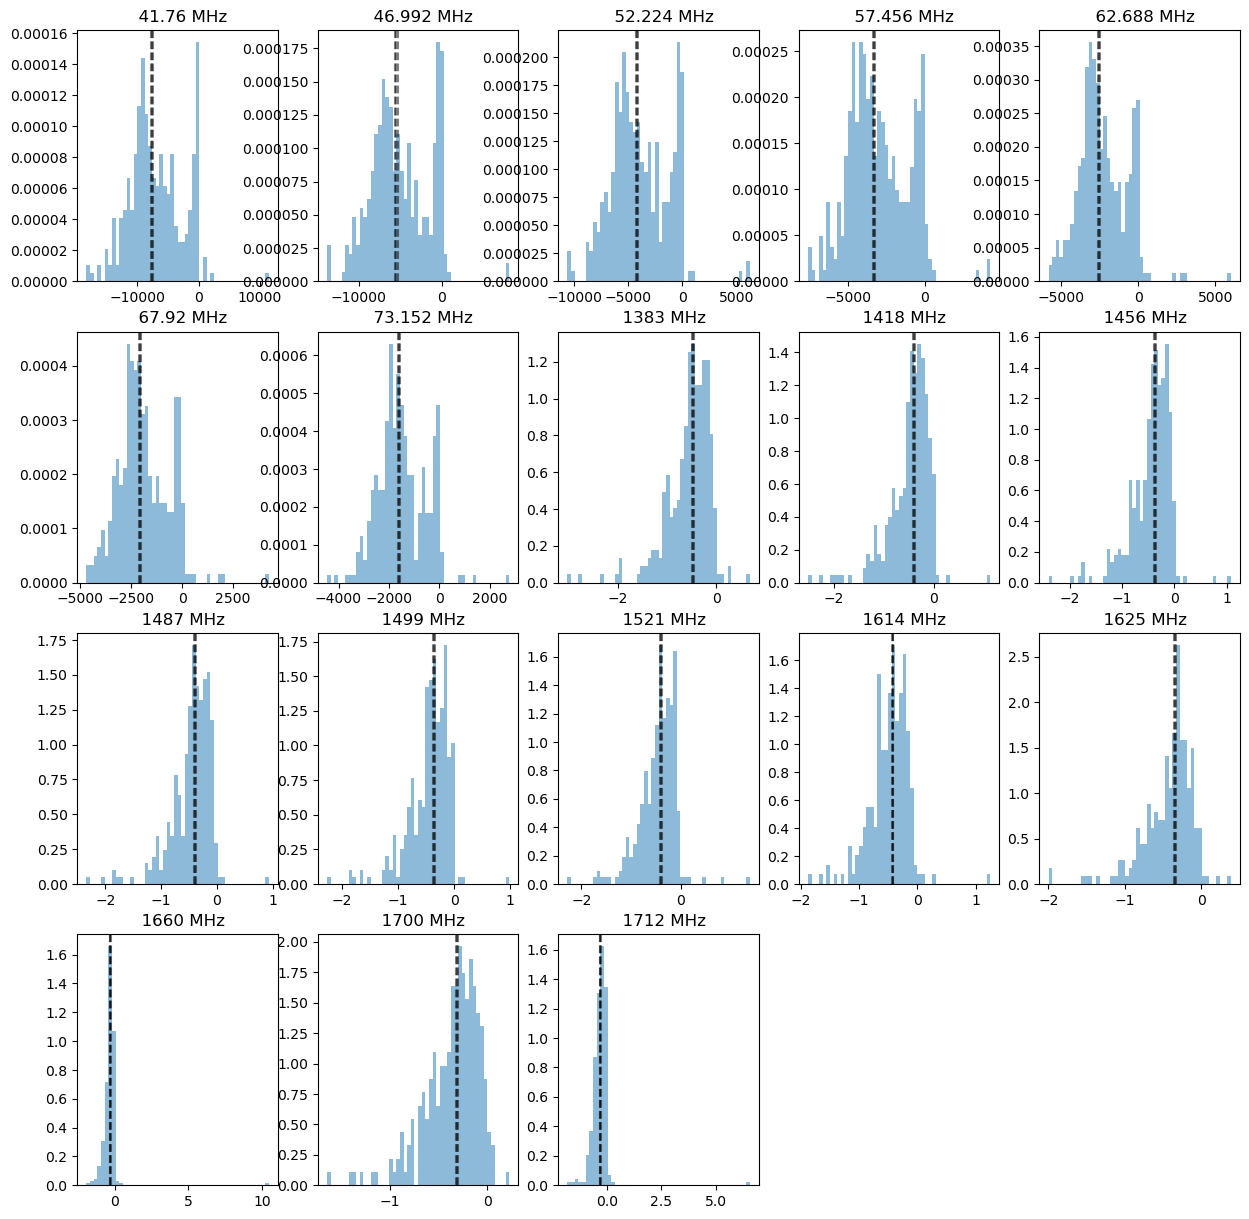

In [10]:
j=0
pl.figure(figsize=(15, 10))

for k in maps.keys():
    if k ==408 : continue
    hp.mollview(off_map[k] , title=f"Offset map for {k} MHz", unit=f"{maps[k].unit}" , cmap='coolwarm',
                sub=(4,5,j+1))
    j+=1
    

pl.figure(figsize=(15, 15))
j=0
for k  in maps.keys() :
    if k ==408 : continue
    
    pl.subplot(4, 5, j+1)
    pl.title(f"  {k} MHz") 
    pl.hist(np.ma.masked_invalid(off_map[k] ).data.flatten(), bins=50, label=f"{k} MHz", alpha=0.5, density=True)
    pl.axvline ( offsetvals[k].value ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    pl.axvline ( offsetvals[k].value -offerr[k] ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    pl.axvline ( offsetvals[k].value +offerr[k]   ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    j+=1


/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_26291/2586610925.py:6: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log (m.value),  title=f'{fr} MHz'  , sub=(4,5,1+j) , notext=True ,  min=-1,  max=10 , unit = f'log({m.unit})'   , cmap='inferno')


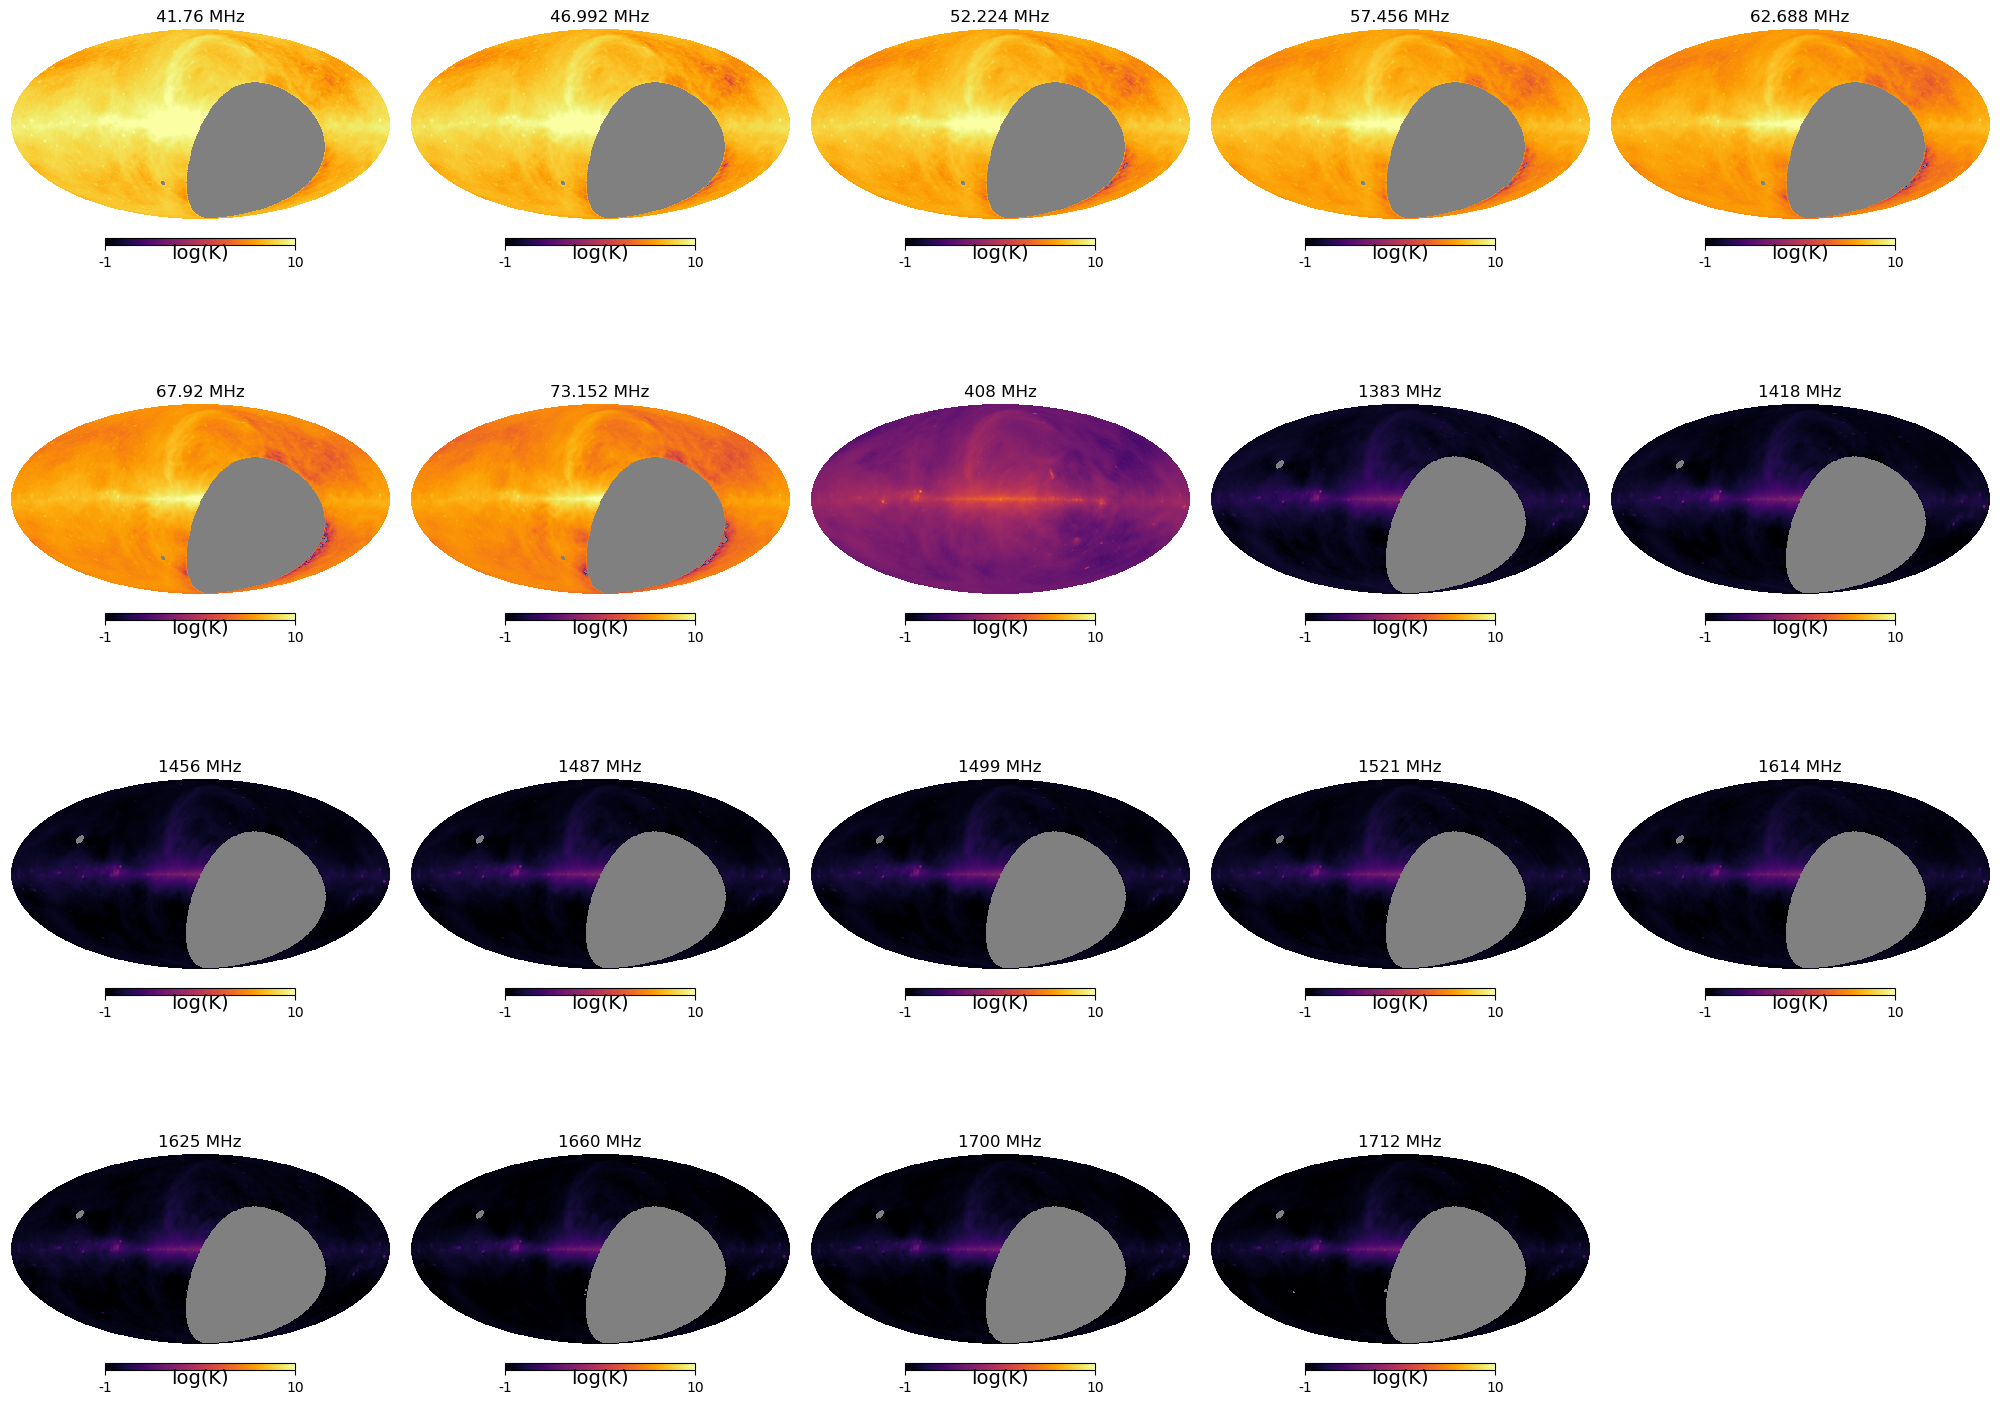

In [11]:
pl.figure(figsize=(20,15)) 

j=0
for fr,m in maps.items():
     
    hp.mollview(np.log (m.value),  title=f'{fr} MHz'  , sub=(4,5,1+j) , notext=True ,  min=-1,  max=10 , unit = f'log({m.unit})'   , cmap='inferno')
    
    j+=1




In [12]:
from astropy.table import Table
t = Table([m for m in maps.values() ] , names=(m for m in maps.keys()))

t.write(f'../inputmaps/fine_north_maps_nside{nside}.fits', format='fits', overwrite=True )